In [1]:
import pandas as pd
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline

In [2]:
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.unicode_minus'] = False

In [3]:
gtex = pd.read_csv('rawdata/abca7_gtex_weights.csv')
gene = parse_refgene("rawdata/abca7.refgene")

In [ ]:
df = pd.read_csv('/rawdata/anon_genotypes.csv', header=None)
df1 = df.index
df1['MAF'] = df.mean(axis=1)
df1['MAC'] = df.sum(axis=1)
rarevars = df1.loc[(df1['MAF'] <= 0.01) & (df1['MAC']>2)]

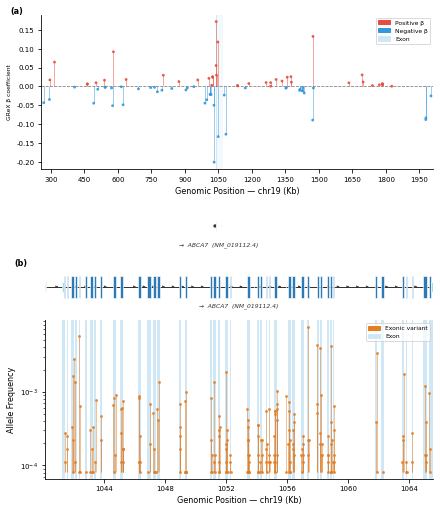

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter, MaxNLocator

def parse_refgene(filepath):
    with open(filepath) as fh:
        line = fh.readline().strip()
    fields = line.split("\t")
    exon_starts = [int(x) for x in fields[9].rstrip(",").split(",")]
    exon_ends   = [int(x) for x in fields[10].rstrip(",").split(",")]

    return dict(
        gene_name = fields[12],
        chrom     = fields[2],
        strand    = fields[3],
        tx_start  = int(fields[4]),
        tx_end    = int(fields[5]),
        cds_start = int(fields[6]),
        cds_end   = int(fields[7]),
        exons     = list(zip(exon_starts, exon_ends)),
    )

def draw_gene_diagram(ax, gene_info):
    exons     = gene_info["exons"]
    tx_start  = gene_info["tx_start"]
    tx_end    = gene_info["tx_end"]
    cds_start = gene_info["cds_start"]
    cds_end   = gene_info["cds_end"]
    strand    = gene_info["strand"]
    gene_name = gene_info["gene_name"]

    CDS_HEIGHT = 0.42
    UTR_HEIGHT = 0.20
    Y_CENTER   = 0.52
    CDS_COLOR  = "#2C7BB6"
    UTR_COLOR  = "#ABD9E9"
    INTRON_COL = "#333333"

    ax.set_ylim(0, 1)

    # Intron
    ax.hlines(Y_CENTER, tx_start, tx_end,
              colors=INTRON_COL, linewidth=1, zorder=1)

    # Strand chevrons
    arrow_spacing = (tx_end - tx_start) / 40
    arrow_dx      = arrow_spacing * 0.35 * (1 if strand == "+" else -1)

    for xpos in np.arange(tx_start + arrow_spacing, tx_end, arrow_spacing):
        if not any(s <= xpos <= e for s, e in exons):
            ax.annotate(
                "", xy=(xpos + arrow_dx, Y_CENTER),
                xytext=(xpos, Y_CENTER),
                arrowprops=dict(
                    arrowstyle="-|>", color=INTRON_COL,
                    lw=0.5, mutation_scale=5,
                ),
                zorder=2,
            )

    # Exon boxes
    for (ex_s, ex_e) in exons:
        bps = sorted({ex_s, ex_e,
                      *([cds_start] if ex_s < cds_start < ex_e else []),
                      *([cds_end]   if ex_s < cds_end   < ex_e else [])})

        for i in range(len(bps) - 1):
            seg_s, seg_e = bps[i], bps[i + 1]
            is_utr = ((seg_s + seg_e) / 2 < cds_start) or \
                     ((seg_s + seg_e) / 2 >= cds_end)
            h     = UTR_HEIGHT if is_utr else CDS_HEIGHT
            color = UTR_COLOR  if is_utr else CDS_COLOR

            ax.add_patch(mpatches.FancyBboxPatch(
                (seg_s, Y_CENTER - h / 2), seg_e - seg_s, h,
                boxstyle="square,pad=0",
                facecolor=color, edgecolor="white", linewidth=0.6, zorder=3,
            ))

    # Gene label
    arrow_char = "→" if strand == "+" else "←"
    ax.text(
        (tx_start + tx_end) / 2, 0.10,
        f"{arrow_char}  {gene_name}  (NM_019112.4)",
        ha="center", va="bottom", fontsize=6,
        color="#333333", fontstyle="italic",
    )

    # Clean
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="x", length=0, labelbottom=False)

def plot_igv_combined(gtex, rarevars, gene_info):

    variant_pos_gtex = gtex["POS"].to_numpy()
    effect_sizes     = gtex["weight"].to_numpy()
    colors_gtex      = np.where(effect_sizes > 0, "#E74C3C", "#3498DB")
    variant_pos_rare = rarevars["POS"].to_numpy()
    maf              = rarevars["MAF"].to_numpy()
    log_baseline     = maf.min()
    mb_fmt = FuncFormatter(lambda x, _: f"{x/1e3:.0f}")
    fig = plt.figure(figsize=(6, 7), facecolor="white", layout="constrained")
    gs_outer = gridspec.GridSpec(2, 1, figure=fig)   
    gs_top = gs_outer[0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    gs_bot = gs_outer[1].subgridspec(2, 1, height_ratios=[1, 3], hspace=0)
    ax_gtex_scatter = fig.add_subplot(gs_top[0])
    ax_gtex_gene    = fig.add_subplot(gs_top[1])  
    ax_rare_gene    = fig.add_subplot(gs_bot[0])
    ax_rare_scatter = fig.add_subplot(gs_bot[1], sharex=ax_rare_gene)

    # Exon + gene body shading
    ax_gtex_scatter.axvspan(
        gene_info["tx_start"], gene_info["tx_end"],
        color="#E8F4FD", alpha=0.5, zorder=0,
    )
    for (ex_s, ex_e) in gene_info["exons"]:
        ax_gtex_scatter.axvspan(ex_s, ex_e, color="#D0E8F5", zorder=1, linewidth=0)

    # Zero line + lollipops
    ax_gtex_scatter.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_gtex_scatter.vlines(variant_pos_gtex, 0, effect_sizes,
                           colors=colors_gtex, linewidth=0.8, alpha=0.6, zorder=2)
    ax_gtex_scatter.scatter(variant_pos_gtex, effect_sizes,
                            c=colors_gtex, s=8, zorder=3, alpha=0.9, linewidths=0)

    ax_gtex_scatter.set_ylabel("GReX β coefficient", fontsize=6)
    ax_gtex_scatter.tick_params(axis="y", labelsize=7)
    ax_gtex_scatter.spines[["top", "right"]].set_visible(False)
    ax_gtex_scatter.legend(
        handles=[
            mpatches.Patch(color="#E74C3C", label="Positive β"),
            mpatches.Patch(color="#3498DB", label="Negative β"),
            mpatches.Patch(color="#D0E8F5", label="Exon"),
        ],
        fontsize=6, loc="upper right", framealpha=0.7,
    )

    # Gene diagram
    draw_gene_diagram(ax_rare_gene, gene_info)

    # Exon shading + lollipops
    for (ex_s, ex_e) in gene_info["exons"]:
        ax_rare_scatter.axvspan(ex_s, ex_e, color="#D0E8F5", zorder=1, linewidth=0)

    ax_rare_scatter.vlines(variant_pos_rare, log_baseline, maf,
                           colors="#E67E22", linewidth=0.8, alpha=0.6, zorder=2)
    ax_rare_scatter.scatter(variant_pos_rare, maf,
                            color="#E67E22", s=8, zorder=3, alpha=0.9, linewidths=0)

    ax_rare_scatter.set_yscale("log")
    ax_rare_scatter.set_ylabel("Allele Frequency", fontsize=8)
    ax_rare_scatter.tick_params(labelsize=7)
    ax_rare_scatter.spines[["top", "right"]].set_visible(False)
    ax_rare_scatter.legend(
        handles=[
            mpatches.Patch(color="#E67E22", label="Exonic variant"),
            mpatches.Patch(color="#D0E8F5", label="Exon"),
        ],
        fontsize=6, loc="upper right", framealpha=0.7,
    )

    x_min_gtex = variant_pos_gtex.min() - 10_000
    x_max_gtex = variant_pos_gtex.max() + 10_000
    ax_gtex_scatter.set_xlim(x_min_gtex, x_max_gtex) 
    ax_gtex_gene.set_xlim(x_min_gtex, x_max_gtex)
    ax_rare_gene.set_xlim(             
        gene_info["tx_start"], gene_info["tx_end"],
    )

    ax_gtex_scatter.xaxis.set_major_locator(MaxNLocator(nbins=12, prune="both"))
    ax_rare_scatter.xaxis.set_major_locator(MaxNLocator(nbins=8, prune="both"))

    ax_gtex_scatter.xaxis.set_major_formatter(mb_fmt)
    ax_rare_scatter.xaxis.set_major_formatter(mb_fmt)
    
    plt.setp(ax_gtex_scatter.get_xticklabels(), visible=True)
    plt.setp(ax_rare_scatter.get_xticklabels(), visible=True)
    

    ax_gtex_scatter.tick_params(axis="x", labelbottom=True, labelsize=7)
    ax_gtex_scatter.set_xlabel(
        f"Genomic Position — {gene_info['chrom']} (Kb)", fontsize=8,
    )
    ax_rare_scatter.tick_params(axis="x", labelbottom=True, labelsize=7)
    ax_rare_scatter.set_xlabel(
        f"Genomic Position — {gene_info['chrom']} (Kb)", fontsize=8,
    )

    for ax, label in [(ax_gtex_scatter, "(a)"), (ax_rare_gene, "(b)")]:
        ax.text(
            -0.08, 1.05, label,
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="top", ha="left",
        )

   # plt.tight_layout()
    plt.savefig("fig1.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_igv_combined(gtex, rarevars, gene)